# AirSight GRU Forecasting Model

This notebook develops and evaluates a GRU model for forecasting hourly scheduled flight counts at KKIA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


In [2]:
# Set a random seed for reproducible results
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Select the available processing device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


## 1. Load the Traffic Dataset

In [3]:
traffic_data = pd.read_csv(
    'model_ready_traffic.csv',
    parse_dates=['hour']
)

traffic_data = (
    traffic_data
    .sort_values('hour')
    .reset_index(drop=True)
)

print("Dataset shape:", traffic_data.shape)
print("Start time:", traffic_data['hour'].min())
print("End time:", traffic_data['hour'].max())
print("Missing values:", traffic_data.isna().sum().sum())
print("Time is sorted:", traffic_data['hour'].is_monotonic_increasing)

display(traffic_data.head())

Dataset shape: (4857, 31)
Start time: 2025-03-21 21:00:00+00:00
End time: 2025-10-10 05:00:00+00:00
Missing values: 0
Time is sorted: True


,hour,flight_count,arrival,departure,terminal_1_count,terminal_2_count,terminal_3_count,terminal_4_count,terminal_5_count,unique_airlines,...,lag_3h,lag_24h,lag_48h,lag_168h,rolling_mean_3h,rolling_mean_24h,rolling_std_24h,target_t1,target_t2,target_t3
0,2025-03-21 21:00:00+00:00,26,14,12,5,2,1,4,14,10,...,31.0,25.0,24.0,26.0,34.000000,25.708333,4.804700,16.0,22.0,27.0
1,2025-03-21 22:00:00+00:00,16,9,7,1,0,3,0,12,7,...,36.0,20.0,20.0,19.0,32.333333,25.750000,4.802626,22.0,27.0,17.0
2,2025-03-21 23:00:00+00:00,22,10,12,2,0,4,6,10,9,...,35.0,20.0,20.0,24.0,25.666667,25.583333,5.072660,27.0,17.0,20.0
3,2025-03-22 00:00:00+00:00,27,18,9,5,0,7,4,11,11,...,26.0,23.0,24.0,22.0,21.333333,25.666667,4.992748,17.0,20.0,25.0
4,2025-03-22 01:00:00+00:00,17,7,10,0,0,5,1,11,8,...,16.0,19.0,20.0,16.0,21.666667,25.833333,4.966555,20.0,25.0,20.0


## 2. Time-Based Data Split

In [4]:
total_rows = len(traffic_data)

train_end = int(total_rows * 0.70)
validation_end = int(total_rows * 0.85)

forecast_horizon = 3

train_data = traffic_data.iloc[
    :train_end - forecast_horizon
].copy()

validation_data = traffic_data.iloc[
    train_end:validation_end - forecast_horizon
].copy()

test_data = traffic_data.iloc[
    validation_end:
].copy()

print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))
print("Test rows:", len(test_data))

print("\nTraining period:")
print(train_data['hour'].min(), "to", train_data['hour'].max())

print("\nValidation period:")
print(validation_data['hour'].min(), "to", validation_data['hour'].max())

print("\nTest period:")
print(test_data['hour'].min(), "to", test_data['hour'].max())

Training rows: 3396
Validation rows: 726
Test rows: 729

Training period:
2025-03-21 21:00:00+00:00 to 2025-08-10 08:00:00+00:00

Validation period:
2025-08-10 12:00:00+00:00 to 2025-09-09 17:00:00+00:00

Test period:
2025-09-09 21:00:00+00:00 to 2025-10-10 05:00:00+00:00


## 3. Select Features and Targets

In [5]:
target_cols = [
    'target_t1',
    'target_t2',
    'target_t3'
]

feature_cols = [
    column
    for column in traffic_data.columns
    if column not in ['hour'] + target_cols
]

print("Number of features:", len(feature_cols))
print("Target columns:", target_cols)
print("\nFeature columns:")
print(feature_cols)

assert not set(feature_cols).intersection(target_cols)

Number of features: 27
Target columns: ['target_t1', 'target_t2', 'target_t3']

Feature columns:
['flight_count', 'arrival', 'departure', 'terminal_1_count', 'terminal_2_count', 'terminal_3_count', 'terminal_4_count', 'terminal_5_count', 'unique_airlines', 'unique_aircraft_models', 'unique_routes', 'hour_of_day', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_3h', 'rolling_mean_24h', 'rolling_std_24h']


## 4. Scale the Input Features

In [6]:
# Create the scaler
feature_scaler = StandardScaler()

# Learn scaling values from training data only
feature_scaler.fit(
    train_data[feature_cols]
)

# Apply the same scaling to the full dataset
scaled_features = feature_scaler.transform(
    traffic_data[feature_cols]
).astype(np.float32)

# Keep the three targets in their original flight-count scale
targets = traffic_data[target_cols].to_numpy(
    dtype=np.float32
)

print("Scaled features shape:", scaled_features.shape)
print("Targets shape:", targets.shape)

Scaled features shape: (4857, 27)
Targets shape: (4857, 3)


## 5. Create 24-Hour Sequences

In [7]:
lookback = 24

def create_sequences(
    features,
    targets,
    start_index,
    end_index,
    lookback
):
    X_sequences = []
    y_sequences = []

    for current_index in range(start_index, end_index):
        sequence_start = current_index - lookback + 1

        # Skip rows that do not have 24 hours of history
        if sequence_start < 0:
            continue

        X_sequences.append(
            features[sequence_start:current_index + 1]
        )

        y_sequences.append(
            targets[current_index]
        )

    return (
        np.array(X_sequences, dtype=np.float32),
        np.array(y_sequences, dtype=np.float32)
    )

In [8]:
# Define the valid forecast-origin boundaries
train_start = 0
train_stop = train_end - forecast_horizon

validation_start = train_end
validation_stop = validation_end - forecast_horizon

test_start = validation_end
test_stop = total_rows

# Create training sequences
X_train, y_train = create_sequences(
    scaled_features,
    targets,
    train_start,
    train_stop,
    lookback
)

# Create validation sequences
X_validation, y_validation = create_sequences(
    scaled_features,
    targets,
    validation_start,
    validation_stop,
    lookback
)

# Create test sequences
X_test, y_test = create_sequences(
    scaled_features,
    targets,
    test_start,
    test_stop,
    lookback
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3373, 24, 27)
y_train shape: (3373, 3)

X_validation shape: (726, 24, 27)
y_validation shape: (726, 3)

X_test shape: (729, 24, 27)
y_test shape: (729, 3)


## 6. Prepare PyTorch DataLoaders

In [9]:
# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)

X_validation_tensor = torch.from_numpy(X_validation)
y_validation_tensor = torch.from_numpy(y_validation)

X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

# Combine inputs and targets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Create batches
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 106
Validation batches: 23
Test batches: 23


## 7. Build the GRU Model

In [10]:
class GRUForecastModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        num_layers=1
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        gru_output, _ = self.gru(x)

        last_time_step = gru_output[:, -1, :]

        predictions = self.output_layer(
            last_time_step
        )

        return predictions
 

In [11]:
input_size = len(feature_cols)
hidden_size = 64
output_size = len(target_cols)
num_layers = 1

model = GRUForecastModel(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    num_layers=num_layers
).to(device)

print(model)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Total trainable parameters:", total_parameters)

GRUForecastModel(
  (gru): GRU(27, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=3, bias=True)
)
Total trainable parameters: 18051


## 8. Set Up Loss and Optimizer

In [12]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## 9. Train the GRU Model

Training performance is monitored using the validation set.
The model with the lowest validation loss is kept.

In [14]:
from copy import deepcopy

max_epochs = 50
patience = 7

best_validation_loss = float('inf')
best_model_state = None
best_epoch = 0
epochs_without_improvement = 0

train_losses = []
validation_losses = []

In [15]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(train_loader.dataset)

In [16]:
def evaluate_loss(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(data_loader.dataset)

In [17]:
for epoch in range(1, max_epochs + 1):

    # Train for one complete epoch
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Evaluate without updating the weights
    validation_loss = evaluate_loss(
        model, validation_loader, criterion, device
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_loss:.4f} | "
        f"Validation MSE: {validation_loss:.4f}"
    )

    # Keep an independent copy of the best weights
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    # Stop when validation performance stops improving
    if epochs_without_improvement >= patience:
        print("Early stopping.")
        break

# Restore the model with the lowest validation loss
model.load_state_dict(best_model_state)

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation MSE: {best_validation_loss:.4f}")

Epoch 01 | Train MSE: 718.3326 | Validation MSE: 581.8004
Epoch 02 | Train MSE: 366.8475 | Validation MSE: 326.2464
Epoch 03 | Train MSE: 199.4996 | Validation MSE: 188.6396
Epoch 04 | Train MSE: 115.3128 | Validation MSE: 117.0698
Epoch 05 | Train MSE: 76.7091 | Validation MSE: 82.3200
Epoch 06 | Train MSE: 61.1496 | Validation MSE: 66.4182
Epoch 07 | Train MSE: 53.7290 | Validation MSE: 91.1364
Epoch 08 | Train MSE: 43.1234 | Validation MSE: 40.8141
Epoch 09 | Train MSE: 33.2069 | Validation MSE: 32.9983
Epoch 10 | Train MSE: 30.1727 | Validation MSE: 29.4076
Epoch 11 | Train MSE: 27.9297 | Validation MSE: 26.2247
Epoch 12 | Train MSE: 25.2704 | Validation MSE: 24.3129
Epoch 13 | Train MSE: 23.8785 | Validation MSE: 23.0013
Epoch 14 | Train MSE: 22.4388 | Validation MSE: 21.8764
Epoch 15 | Train MSE: 21.2450 | Validation MSE: 20.7702
Epoch 16 | Train MSE: 23.0376 | Validation MSE: 20.8042
Epoch 17 | Train MSE: 19.4261 | Validation MSE: 19.7411
Epoch 18 | Train MSE: 18.1473 | Validati

## 10. Review Training and Validation Loss

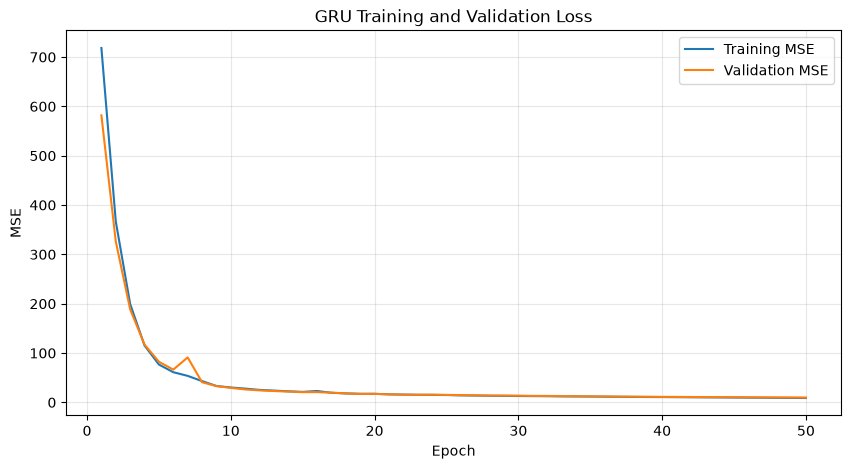

In [18]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_losses, label='Training MSE')
plt.plot(epochs, validation_losses, label='Validation MSE')

plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('GRU Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

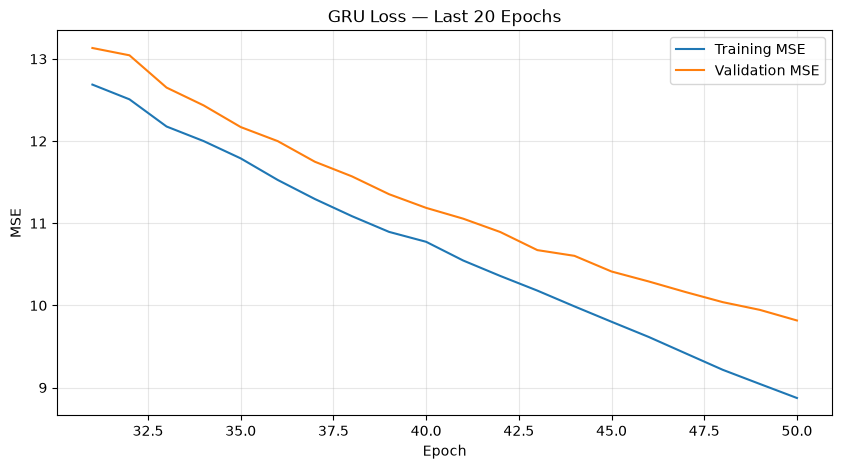

In [19]:
start = max(0, len(train_losses) - 20)
epochs = range(start + 1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses[start:], label="Training MSE")
plt.plot(epochs, validation_losses[start:], label="Validation MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("GRU Loss — Last 20 Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
# Continue training from the next epoch
start_epoch = len(train_losses) + 1
max_epochs = 100

for epoch in range(start_epoch, max_epochs + 1):
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    validation_loss = evaluate_loss(
        model, validation_loader, criterion, device
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"Train MSE: {train_loss:.4f} | "
        f"Validation MSE: {validation_loss:.4f}"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping.")
        break

# Restore the weights with the lowest validation loss
model.load_state_dict(best_model_state)

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation MSE: {best_validation_loss:.4f}")

Epoch 51 | Train MSE: 8.6905 | Validation MSE: 9.7281
Epoch 52 | Train MSE: 8.5450 | Validation MSE: 9.5807
Epoch 53 | Train MSE: 8.3926 | Validation MSE: 9.4875
Epoch 54 | Train MSE: 8.1924 | Validation MSE: 9.4400
Epoch 55 | Train MSE: 8.0075 | Validation MSE: 9.2773
Epoch 56 | Train MSE: 7.8048 | Validation MSE: 9.1676
Epoch 57 | Train MSE: 7.6446 | Validation MSE: 9.1304
Epoch 58 | Train MSE: 7.4466 | Validation MSE: 9.0292
Epoch 59 | Train MSE: 7.2779 | Validation MSE: 8.9077
Epoch 60 | Train MSE: 7.1046 | Validation MSE: 8.9147
Epoch 61 | Train MSE: 6.9229 | Validation MSE: 8.9636
Epoch 62 | Train MSE: 6.8833 | Validation MSE: 9.0005
Epoch 63 | Train MSE: 6.6387 | Validation MSE: 8.9660
Epoch 64 | Train MSE: 6.5730 | Validation MSE: 8.9348
Epoch 65 | Train MSE: 6.3837 | Validation MSE: 8.7036
Epoch 66 | Train MSE: 6.2718 | Validation MSE: 9.1838
Epoch 67 | Train MSE: 6.1684 | Validation MSE: 8.9364
Epoch 68 | Train MSE: 6.0291 | Validation MSE: 8.7366
Epoch 69 | Train MSE: 5.9130

## Evaluate the GRU on the Test Set

Use the selected model to predict flight counts one, two, and three hours ahead.

In [21]:
def collect_predictions(model, data_loader, device):
    model.eval()

    actual_values = []
    predicted_values = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)

            predictions = model(X_batch)

            actual_values.append(y_batch.cpu().numpy())
            predicted_values.append(predictions.cpu().numpy())

    return (
        np.concatenate(actual_values, axis=0),
        np.concatenate(predicted_values, axis=0)
    )


y_true, y_pred = collect_predictions(model, test_loader, device)

print("Actual values shape:", y_true.shape)
print("Predictions shape:", y_pred.shape)

Actual values shape: (729, 3)
Predictions shape: (729, 3)


In [22]:
def calculate_smape(actual, predicted):
    denominator = np.abs(actual) + np.abs(predicted)

    ratios = np.divide(
        2 * np.abs(predicted - actual),
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator != 0
    )

    return np.mean(ratios) * 100


results = []

for i in range(len(target_cols)):
    actual = y_true[:, i]
    predicted = y_pred[:, i]

    results.append({
        "Horizon": f"t+{i + 1}",
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "sMAPE (%)": calculate_smape(actual, predicted)
    })

test_results = pd.DataFrame(results)
display(test_results.round(3))

,Horizon,MAE,RMSE,sMAPE (%)
0,t+1,2.287,3.095,8.161
1,t+2,2.328,3.228,8.364
2,t+3,2.186,2.904,7.952


## Actual vs. Predicted Flight Counts

Compare actual and predicted counts for the first 72 forecast origins in the test set, for each forecast horizon.

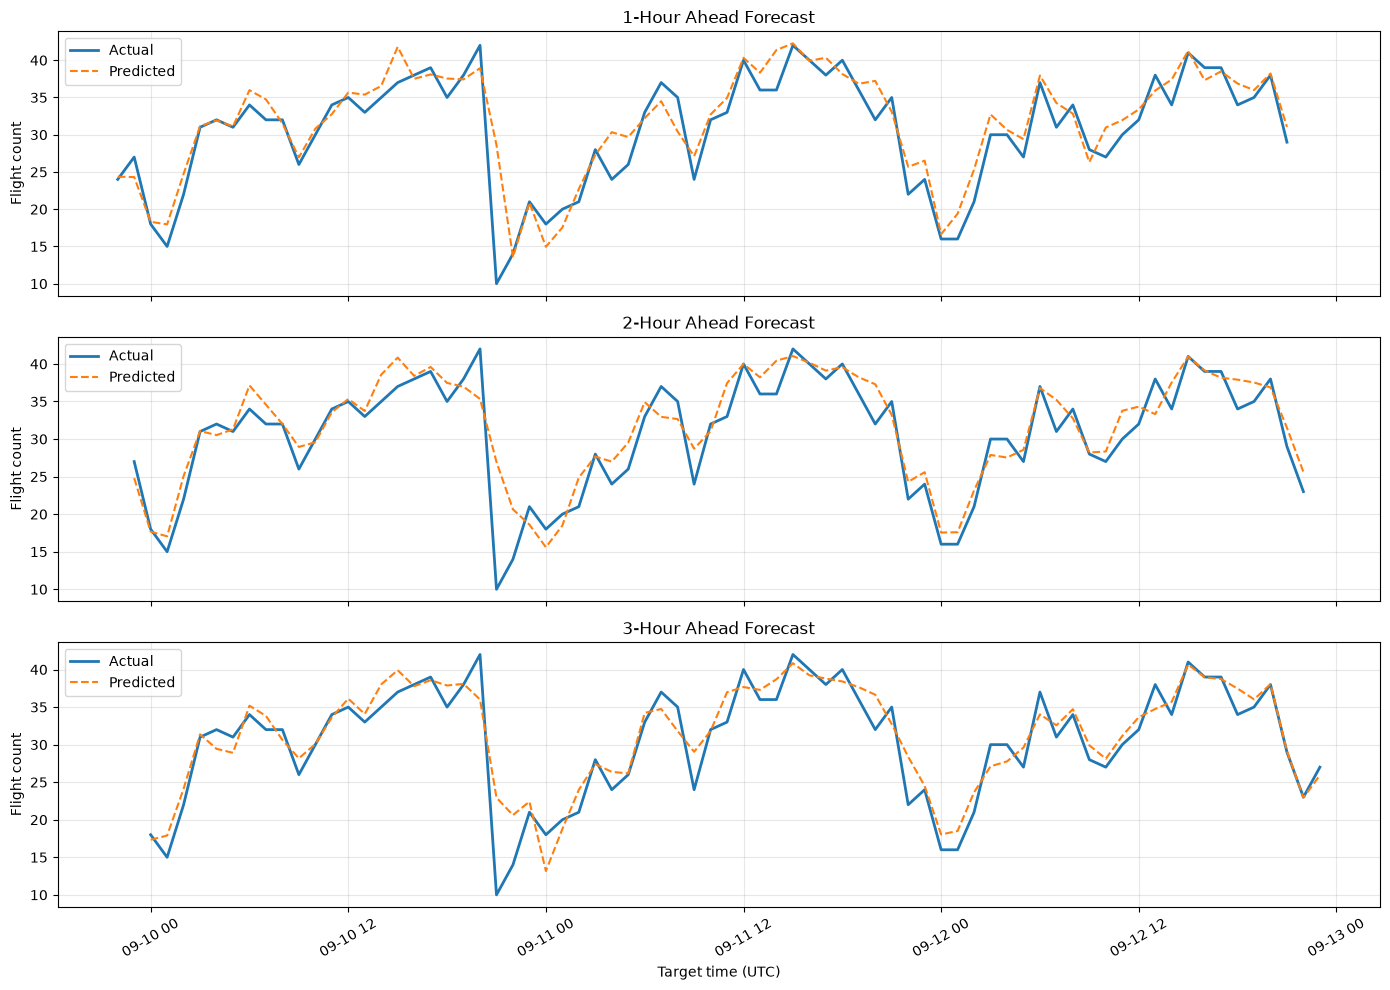

In [24]:
n_points = min(72, len(y_true))

origin_times = test_data["hour"].reset_index(drop=True)
assert len(origin_times) == len(y_true)

# Use the same time axis for all three plots
fig, axes = plt.subplots(
    3, 1, figsize=(14, 10), sharex=True
)

for i, ax in enumerate(axes):
    horizon = i + 1

    # Match each prediction to its target time
    target_times = (
        origin_times.iloc[:n_points]
        + pd.Timedelta(hours=horizon)
    )

    ax.plot(
        target_times,
        y_true[:n_points, i],
        label="Actual",
        linewidth=2
    )

    ax.plot(
        target_times,
        y_pred[:n_points, i],
        label="Predicted",
        linestyle="--"
    )

    ax.set_title(f"{horizon}-Hour Ahead Forecast")
    ax.set_ylabel("Flight count")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Target time (UTC)")
axes[-1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Save the Traffic-Only Model and Results

Save the selected model weights, feature scaler, model settings, and test results for later use.

In [25]:
from pathlib import Path
import joblib

save_dir = Path("artifacts/gru_traffic_only")
save_dir.mkdir(parents=True, exist_ok=True)

# Save the selected model weights and settings
torch.save(
    {
        "model_state_dict": {
            name: value.detach().cpu()
            for name, value in model.state_dict().items()
        },
        "input_size": model.gru.input_size,
        "hidden_size": model.gru.hidden_size,
        "num_layers": model.gru.num_layers,
        "output_size": model.output_layer.out_features,
        "lookback": lookback,
        "feature_cols": list(feature_cols),
        "target_cols": list(target_cols),
        "best_epoch": best_epoch,
        "best_validation_mse": best_validation_loss
    },
    save_dir / "model.pt"
)

# Save the scaler fitted on training data
joblib.dump(feature_scaler, save_dir / "feature_scaler.joblib")

# Save test metrics without rounding
test_results.to_csv(save_dir / "test_metrics.csv", index=False)

# Save actual values and predictions with their timestamps
predictions_table = pd.DataFrame({
    "origin_time": test_data["hour"].reset_index(drop=True)
})

assert len(predictions_table) == len(y_true) == len(y_pred)

for i in range(len(target_cols)):
    horizon = i + 1

    predictions_table[f"target_time_t{horizon}"] = (
        predictions_table["origin_time"]
        + pd.Timedelta(hours=horizon)
    )
    predictions_table[f"actual_t{horizon}"] = y_true[:, i]
    predictions_table[f"predicted_t{horizon}"] = y_pred[:, i]

predictions_table.to_csv(
    save_dir / "test_predictions.csv", index=False
)

print("Saved to:", save_dir.resolve())

Saved to: C:\Users\gedoo\AirSight\artifacts\gru_traffic_only


## Traffic-Only GRU Summary

- The model uses the past 24 hours of traffic features to predict flight counts 1, 2, and 3 hours ahead.
- Data was split by time without shuffling, with a 3-hour gap between sets to prevent targets from crossing split boundaries.
- The feature scaler was fitted on training data only.
- Early stopping selected epoch 91 based on the lowest validation MSE.

### Test Results

| Forecast horizon | MAE | RMSE | sMAPE (%) |
|---|---:|---:|---:|
| 1 hour ahead | 2.287 | 3.095 | 8.161 |
| 2 hours ahead | 2.328 | 3.228 | 8.364 |
| 3 hours ahead | 2.186 | 2.904 | 7.952 |

In the plotted test period, predictions followed most rises and falls but missed some sharp changes.

The model, scaler, and test results were saved. 